In [53]:
import pandas as pd
import numpy as np

## ขั้นตอนที่ 1 นำเข้าข้อมูล

In [54]:

# tennins 
df = pd.read_excel('./datasets/Golf.xlsx')
# df = df.drop(columns = 'order')
df

,order,Outlook,Temperature,Humidity,Windy,Play
0,1,Sunny,Hot,High,No,No
1,2,Sunny,Hot,High,Yes,No
2,3,Overcast,Hot,High,No,Yes
3,4,Rainy,Mild,High,No,Yes
4,5,Rainy,Cool,Normal,No,Yes
5,6,Rainy,Cool,Normal,Yes,No
6,7,Overcast,Cool,Normal,Yes,Yes
7,8,Sunny,Mild,High,No,No
8,9,Sunny,Cool,Normal,No,Yes
9,10,Rainy,Mild,Normal,No,Yes


## ขั้นตอนที่ 2 ปลงข้อมูลเชิงหมวดหมู่ (Label Encoding)

In [55]:
# นำเข้า module แปลงข้อมูล 
from sklearn.preprocessing import LabelEncoder

In [56]:
# เรียกใช้งาน 
encoder = LabelEncoder()

In [57]:
# พิจารณา Columns 
df


,order,Outlook,Temperature,Humidity,Windy,Play
0,1,Sunny,Hot,High,No,No
1,2,Sunny,Hot,High,Yes,No
2,3,Overcast,Hot,High,No,Yes
3,4,Rainy,Mild,High,No,Yes
4,5,Rainy,Cool,Normal,No,Yes
5,6,Rainy,Cool,Normal,Yes,No
6,7,Overcast,Cool,Normal,Yes,Yes
7,8,Sunny,Mild,High,No,No
8,9,Sunny,Cool,Normal,No,Yes
9,10,Rainy,Mild,Normal,No,Yes


In [58]:
# แปลงข้อมูลทีละ Col 
# df["Out_Label"] = encoder.fit_transform(df["Outlook"])
# df["Temperature_label"] = encoder.fit_transform(df["Temperature"])




In [59]:
from sklearn.preprocessing import LabelEncoder

encoders = {}  # เก็บ encoder ของแต่ละคอลัมน์

for col in df.columns:
    le = LabelEncoder()           # สร้าง encoder ใหม่สำหรับคอลัมน์นั้น
    df[col] = le.fit_transform(df[col])
    encoders[col] = le            # เก็บ encoder ไว้ใน dict

print(df.head())


   order  Outlook  Temperature  Humidity  Windy  Play
0      0        2            1         0      0     0
1      1        2            1         0      1     0
2      2        0            1         0      0     1
3      3        1            2         0      0     1
4      4        1            0         1      0     1


## ขั้นตอนที่ 3: สร้าง Decision Tree Model

In [60]:
from sklearn.tree import DecisionTreeClassifier

X = df.drop("Play", axis=1)   # ตัวแปรอิสระ
y = df["Play"]                # ตัวแปรเป้าหมาย

# ถ้าอยากใช้ Entropy
model = DecisionTreeClassifier(criterion="entropy", random_state=0)
# ถ้าอยากใช้ Gini
# model = DecisionTreeClassifier(criterion="gini", random_state=0)

model.fit(X, y)


,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## ขั้นตอนที่ 4: แสดงต้นไม้

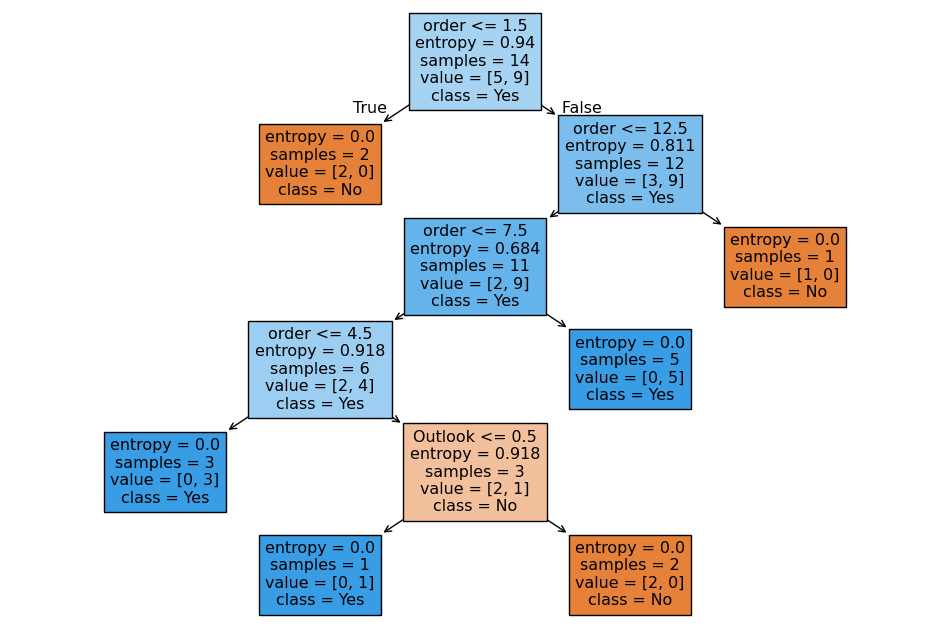

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))              # ตั้งขนาดกราฟ (กว้าง 12 สูง 8)
plot_tree(model,
          feature_names=X.columns,      # ชื่อฟีเจอร์ เช่น Outlook, Humidity
          class_names=["No", "Yes"],    # ชื่อคลาสของ y (0 = No, 1 = Yes)
          filled=True)                  # เติมสีตามคลาสเพื่ออ่านง่าย
plt.show()



Outlook <= 0.5
entropy = 0.94
samples = 14
value = [5, 9]
class = Yes

| คำอธิบาย         | ความหมาย                                                                                             |
| ---------------- | ---------------------------------------------------------------------------------------------------- |
| `Outlook <= 0.5` | เงื่อนไขแรกที่โมเดลใช้แบ่งข้อมูล — ถ้า "Outlook" น้อยกว่าหรือเท่ากับ 0.5 (เช่น Overcast) จะไปทางซ้าย |
| `entropy = 0.94` | ค่าความไม่บริสุทธิ์ของ node เริ่มต้น (ยิ่งใกล้ 1 แสดงว่าข้อมูลผสมกันมาก)                             |
| `samples = 14`   | จำนวนตัวอย่างใน node นี้ทั้งหมด 14 ตัว                                                               |
| `value = [5, 9]` | มี 5 ตัวอย่างเป็น “No”, 9 ตัวอย่างเป็น “Yes”                                                         |
| `class = Yes`    | ส่วนใหญ่เป็น “Yes” จึงจัด node นี้เป็น class “Yes”                                                   |



## ซ้าย 

entropy = 0.0
samples = 4
value = [0, 4]
class = Yes

| หมายถึงกรณีที่ Outlook เป็น Overcast

| ค่า Entropy = 0 → ข้อมูล “บริสุทธิ์สมบูรณ์” (ทุกตัวเป็น Yes)

| สรุป: ถ้า Overcast → เล่น (Play = Yes)

## ขวา
Humidity <= 0.5
entropy = 1.0
samples = 10
value = [5, 5]
class = No

หลังจากตัด Overcast ออกแล้ว เหลือข้อมูลที่มี Outlook เป็น Sunny หรือ Rainy

ค่า Entropy = 1 → ข้อมูลผสม (ครึ่ง Yes ครึ่ง No)

โมเดลจะพยายามหา feature ต่อไปที่ทำให้ node บริสุทธิ์ขึ้น — นั่นคือ “Humidity”


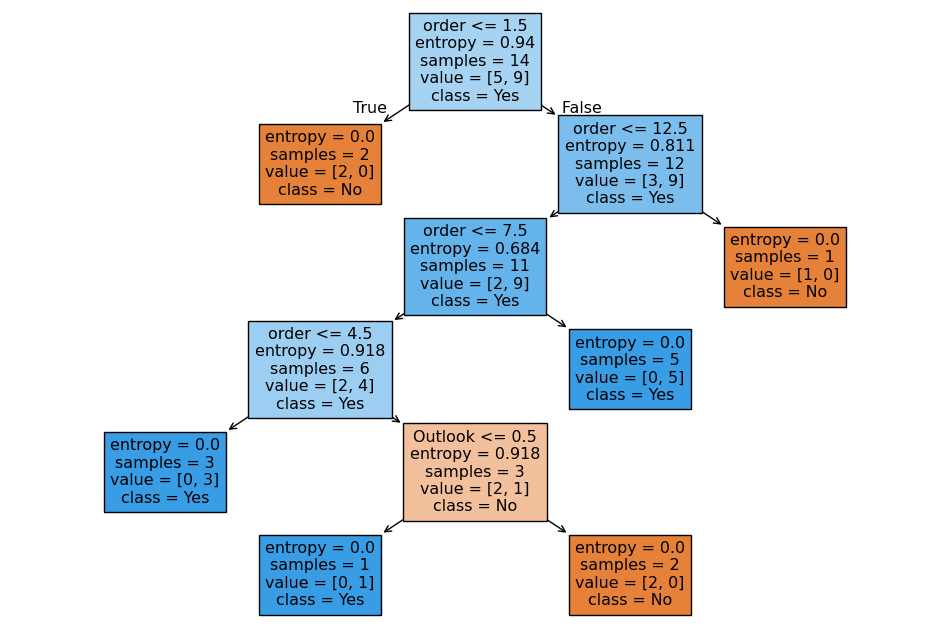

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# ชื่อคอลัมน์ของ feature
feature_names = X.columns


# ชื่อ class (เปลี่ยนตัวเลขกลับเป็น "No", "Yes")
class_names = encoders["Play"].classes_

plt.figure(figsize=(12, 8))
plot_tree(model,
          feature_names=feature_names,
          class_names=class_names,
          filled=True)
plt.show()






| เงื่อนไข                                      | ผลลัพธ์          |
| --------------------------------------------- | ---------------- |
| ถ้า **Outlook = Overcast**                    | → **Play = Yes** |
| ถ้า **Outlook = Sunny และ Humidity = High**   | → **Play = No**  |
| ถ้า **Outlook = Sunny และ Humidity = Normal** | → **Play = Yes** |
| ถ้า **Outlook = Rainy และ Windy = No**        | → **Play = Yes** |
| ถ้า **Outlook = Rainy และ Windy = Yes**       | → **Play = No**  |


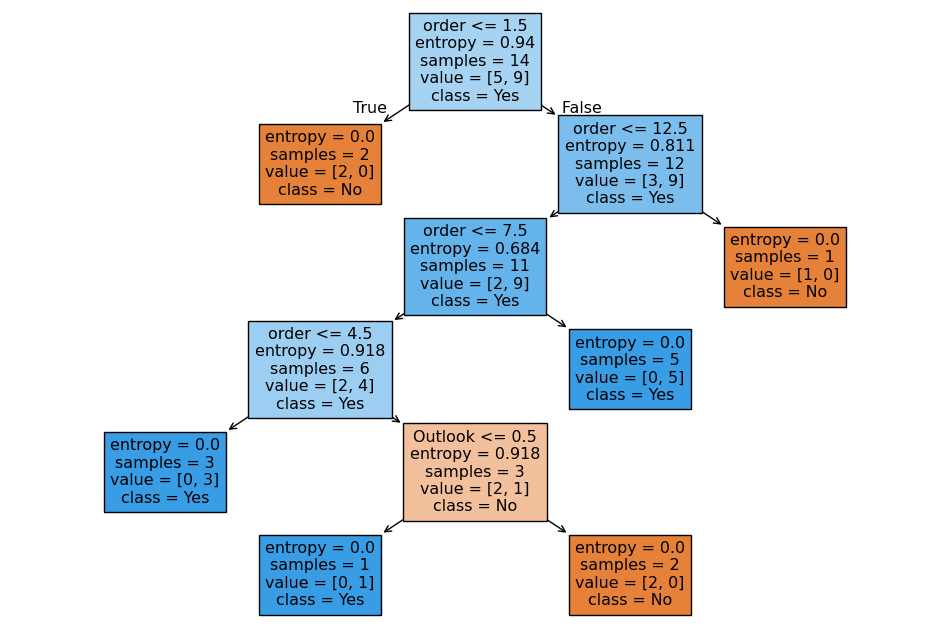

In [62]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# ชื่อคอลัมน์ของ feature
feature_names = X.columns


# ชื่อ class (เปลี่ยนตัวเลขกลับเป็น "No", "Yes")
class_names = encoders["Play"].classes_

plt.figure(figsize=(12, 8))
plot_tree(model,
          feature_names=feature_names,
          class_names=class_names,
          filled=True)
plt.show()






## ขั้นตอนที่ 5: ทำนายผลใหม่ (ตัวอย่าง)

In [63]:
# ทำนายว่าควร "Play" หรือไม่ 
# วันนี้ Outlook: Sunny, Temperatur: Cool, Humidity: High, Windy: Yes
sample = pd.DataFrame([["Sunny", "Cool", "High", "Yes"]],
                      columns=["Outlook","Temperature","Humidity","Windy"])

# ต้อง encode ด้วย LabelEncoder แบบเดิม
for col in sample.columns:
    sample[col] = encoder.fit_transform(sample[col])

y_pred = model.predict(sample)
print("ผลการทำนาย =", "Play" if y_pred[0]==1 else "Don't Play")


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- order


# 1.  ลองเปลี่ยนจาก Entropy เป็น GINI 
# 2. เปลี่ยนข้อมูลเป็น ByComputer  และใช้ Gini Index 
# 3. เปลี่ยนข้อมูลเป็น ByComputer  และใช้ Entropy Index 
